# Analyzing CoCiP internal processes

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
# Import each CoCiP bypass dataset into a dictionary, similar to epm_bypass_data
cocip_bypass_files = {
    # '110T205L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25/110T205L25-bypass_midnight.nc",
    # '110T218L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/110T218L25-bypass_midnight.nc",
    # '110T225L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T225L25/110T225L25-bypass_midnight.nc",
    '130T205L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T205L25/130T205L25-bypass_midnight.nc",
    # '130T218L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T218L25/130T218L25-bypass_midnight.nc",
    # '130T225L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T225L25/130T225L25-bypass_midnight.nc",
}

# Open each CoCiP bypass dataset and store in a dictionary for easy access
cocip_bypass_data = {}
for test_id, filepath in cocip_bypass_files.items():
    cocip_bypass_data[test_id] = xr.open_dataset(filepath)

# Crystal Density Investigation Plots

## Lagg and Lturb

In [ ]:
# Plot dn_dt_agg and dn_dt_turb for RHi groups 110 and 130
vars_to_plot = ['dn_dt_agg', 'dn_dt_turb']
rhi_groups = ['110', '130']

for rhi in rhi_groups:
    # select tests that start with the RHi prefix (e.g. '110T205L25')
    tests = [k for k in cocip_bypass_data.keys() if k.startswith(rhi)]

    for var in vars_to_plot:
        plt.figure(figsize=(10, 4.5))
        plotted = False
        for test_id in tests:
            ds = cocip_bypass_data[test_id]

            # use the dataset's index coordinate if available
            x = ds['age_hours'].values

            y = ds[var].values
            plt.plot(x, y, label=test_id)
            plotted = True

        plt.xlabel('Contrail Age [hours]')
        plt.ylabel(var)
        plt.title(f"{var} for RHi {rhi}%")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Terminal crystal velocity

In [ ]:
# Plot terminal crystal velocity for RHi groups 110 and 130
vars_to_plot = ['terminal_fall_speed']
rhi_groups = ['110', '130']

for rhi in rhi_groups:
    # select tests that start with the RHi prefix (e.g. '110T205L25')
    tests = [k for k in cocip_bypass_data.keys() if k.startswith(rhi)]

    for var in vars_to_plot:
        plt.figure(figsize=(10, 4.5))
        plotted = False
        for test_id in tests:
            ds = cocip_bypass_data[test_id]

            # use the dataset's index coordinate if available
            x = ds['age_hours'].values

            y = ds[var].values
            plt.plot(x, y, label=test_id)
            plotted = True

        plt.xlabel('Contrail Age [hours]')
        plt.ylabel('Terminal Fall Velocity [m/s]')
        plt.title(f"{var} for RHi {rhi}%")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [ ]:
# Plot terminal crystal velocity for RHi groups 110 and 130
vars_to_plot = ['depth', 'width']
rhi_groups = ['110', '130']

for rhi in rhi_groups:
    # select tests that start with the RHi prefix (e.g. '110T205L25')
    tests = [k for k in cocip_bypass_data.keys() if k.startswith(rhi)]

    for var in vars_to_plot:
        plt.figure(figsize=(10, 4.5))
        plotted = False
        for test_id in tests:
            ds = cocip_bypass_data[test_id]

            # use the dataset's index coordinate if available
            x = ds['age_hours'].values

            y = ds[var].values
            plt.plot(x, y, label=test_id)
            plotted = True

        plt.xlabel('Contrail Age [hours]')
        plt.ylabel('Contrail Dimension [m]')
        plt.title(f"{var} for RHi {rhi}%")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [ ]:
# Plot terminal crystal velocity for RHi groups 110 and 130
vars_to_plot = ['altitude']
rhi_groups = ['110', '130']

for rhi in rhi_groups:
    # select tests that start with the RHi prefix (e.g. '110T205L25')
    tests = [k for k in cocip_bypass_data.keys() if k.startswith(rhi)]

    for var in vars_to_plot:
        plt.figure(figsize=(10, 4.5))
        plotted = False
        for test_id in tests:
            ds = cocip_bypass_data[test_id]

            # use the dataset's index coordinate if available
            x = ds['age_hours'].values

            y = ds[var].values
            plt.plot(x, y, label=test_id)
            plotted = True

        plt.xlabel('Contrail Age [hours]')
        plt.ylabel('Contrail Dimension [m]')
        plt.title(f"{var} for RHi {rhi}%")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Testing met

In [2]:
import numpy as np
import pandas as pd
import sys
import xarray as xr
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib
import run_CoCiP_fxn_lib as cocip_lib

In [6]:
path = "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/110T218L25-met-noon.nc"
cocip110_met_noon = xr.open_dataset(path)

In [ ]:
# Remove the early .to_netcdf() call entirely
# Import APCEMM met data
test_id = '110T205L25'
xr_apcemm_met = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/base_inputs/{test_id}/{test_id}.nc")
# Define the shape of the dataset
longitudes = cocip110_met_noon['longitude'].values
latitudes = cocip110_met_noon['latitude'].values
times = cocip110_met_noon['time'].values
levels = cocip110_met_noon['level'].values
new_shape = (len(longitudes), len(latitudes), len(levels), len(times))
# Materialize arrays immediately (no lazy broadcast views)
air_temperature = np.ascontiguousarray(
    np.broadcast_to(
        np.flip(xr_apcemm_met['temperature'][:,0].values)[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)
)

relative_humidity = np.ascontiguousarray(
    np.broadcast_to(
        np.flip(xr_apcemm_met['relative_humidity_ice'][:,0].values)[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)
)

T_base = air_temperature[0, 0, :, 0]
RHi_base = relative_humidity[0, 0, :, 0]
pres_base = levels * 100
P_sat_w = lib.compute_Psat_w(T_base)
P_sat_i = lib.compute_Psat_i(T_base)
T0 = 273.15
q_base = (RHi_base * P_sat_i / P_sat_w) * (1 / (0.263 * pres_base)) * np.exp(
    (17.67 * (T_base - T0)) / (T_base - 29.65)
)
specific_humidity = np.ascontiguousarray(
    np.broadcast_to(
        q_base[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)
)

# Assign updated variables
cocip110_met_noon['air_temperature'] = (('longitude', 'latitude', 'level', 'time'), air_temperature)
cocip110_met_noon['relative_humidity'] = (('longitude', 'latitude', 'level', 'time'), relative_humidity)
cocip110_met_noon['specific_humidity'] = (('longitude', 'latitude', 'level', 'time'), specific_humidity)

# Single write with compression
encoding = {
    var: {"zlib": True, "complevel": 1, "chunksizes": (1, 1, len(levels), 1)}
    for var in ["air_temperature", "relative_humidity", "specific_humidity"]
}

In [ ]:
# save the updated dataset to a new netCDF file
output_path = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-met-noon.nc"

ds_subset = cocip110_met_noon.sel(
    latitude=slice(30, 60),
    longitude=slice(-60, -30)
)

ds_subset.to_netcdf(output_path, encoding=encoding)

In [ ]:
# plot each variable in the cocip110_met_midnight dataset as a function of altitiude
# time = midnight
# latitude = 45 longitude = -46
variables_to_plot = ['air_temperature', 'relative_humidity', 'specific_humidity']
for var in variables_to_plot:
    plt.figure(figsize=(6, 4))
    plt.plot(cocip110_met_midnight[var].sel(time='2025-06-29T00:00:00', latitude=45, longitude=-46), cocip110_met_midnight['altitude'])
    plt.ylabel('Altitude (m)')
    plt.xlabel(var.replace('_', ' ').title())
    plt.title(f"{var.replace('_', ' ').title()} vs Altitude at Midnight (Lat: 45, Lon: -46)")
    plt.grid()
    plt.tight_layout()
    plt.show()

# Fixing lifetime

In [20]:
import numpy as np

In [ ]:
test_ids = ['110T205L25', '130T205L25']
tod = 'noon' # or 'noon'

cocip_data = {}
for test_id in test_ids:
    file_path = f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-bypass_{tod}_full.nc'
    cocip_data[test_id, tod] = xr.open_dataset(file_path)

In [22]:
# Print which index corresponds to the point where the effective radius slope changes from negative to positive
for (test_id, tod), ds in cocip_data.items():
    r_eff = ds['r_ice_vol'].values
    slope = np.diff(r_eff)
    sign_change_indices = np.where((slope[:-1] < 0) & (slope[1:] > 0))[0] + 1
    print(f"{test_id} at {tod}: Sign change indices for effective radius slope: {sign_change_indices}")

110T205L25 at noon: Sign change indices for effective radius slope: [848]
130T205L25 at noon: Sign change indices for effective radius slope: [635]


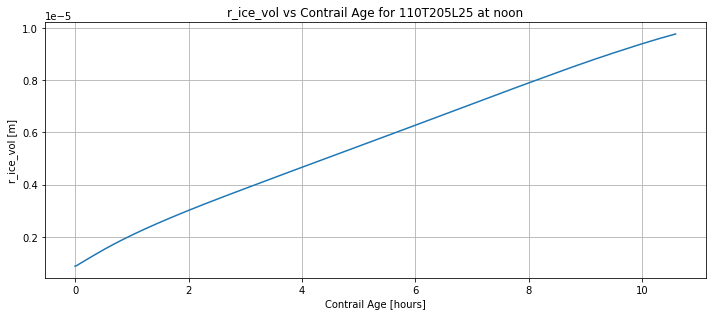

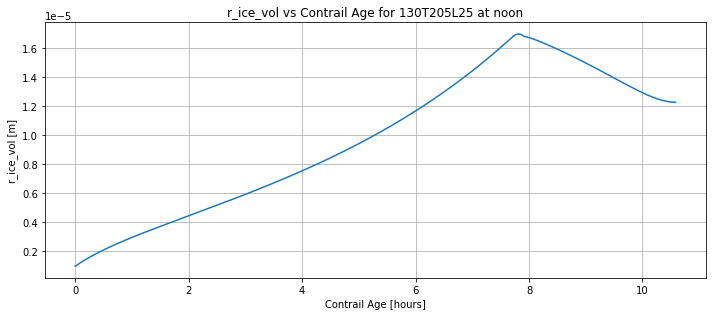

In [23]:
# Plot the r_ice_vol over time for each test
for (test_id, tod), ds in cocip_data.items():
    plt.figure(figsize=(10, 4.5))
    plt.plot(ds['age_hours'][:635], ds['r_ice_vol'][:635])
    plt.xlabel('Contrail Age [hours]')
    plt.ylabel('r_ice_vol [m]')
    plt.title(f"r_ice_vol vs Contrail Age for {test_id} at {tod}")
    plt.grid()
    plt.tight_layout()
    plt.show()

In [ ]:
# open and truncate nc file data to time index prescribed
cocip_110 = 848
cocip_130 = 635 # index to cut off cocip data

# update cocip data with truncated data
for key, ds in cocip_data.items():
    tid, hour = key
    if tid == '110T205L25':
        cocip_data[key] = ds.isel(index=slice(0, cocip_110))
    elif tid == '130T205L25':
        cocip_data[key] = ds.isel(index=slice(0, cocip_130))

# Save the truncated CoCiP datasets to new NetCDF files
for key, ds in cocip_data.items():
    tid, hour = key
    if tid in test_ids:
        output_path = f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{tid}/{tid}-bypass_{tod}.nc'
        ds.to_netcdf(output_path)